# Modelo de ML para Airbnb de Madrid

In [ ]:
pip install category_encoders

In [ ]:
pip install xgboost

In [ ]:
pip install lightgbm

In [1]:
import numpy  as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from joblib import parallel_backend
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

Despues de analizar el DF vamos a proseguir con la realización del modelo empezamos con el preprocesamiento de train en base a lo realizado en el analisis.

In [2]:
#Preprocesamiento train

airbnb_train = pd.read_csv(
    "..\\..\\utils\\airbnb-listings-extract-train.csv",
    sep=';',
    encoding='utf-8'
)

date_scraped = pd.to_datetime(airbnb_train['Last Scraped'], errors='coerce')


#Borrado de columnas
airbnb_train_limpio=airbnb_train.drop(columns=['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 
'Summary', 'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview', 
'Notes', 'Transit', 'Access', 'Interaction', 'House Rules','Thumbnail Url', 'Medium Url', 
'Picture Url', 'XL Picture Url', 'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location', 
'Host About', 'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 'Host Listings Count',
'Host Total Listings Count', 'Host Verifications','Street','Smart Location', 'Country Code', 'Country',
'City', 'State','Market','Calendar Updated','Calendar last Scraped','Geolocation','Has Availability',
'Host Acceptance Rate','Jurisdiction Names','License','Square Feet','Weekly Price','Monthly Price',
'Availability 60','Availability 90','First Review'])
#limpieza de nulos
cols = [
    'Review Scores Rating',
    'Review Scores Accuracy',
    'Review Scores Cleanliness',
    'Review Scores Checkin',
    'Review Scores Communication',
    'Review Scores Location',
    'Review Scores Value',
    'Bathrooms',
    'Beds',
    'Bedrooms',
    'Calculated host listings count',
    'Host Response Rate',
]

medians = {}
for col in cols:
    medians[col] = airbnb_train_limpio[col].median()
    airbnb_train_limpio[col] = airbnb_train_limpio[col].fillna(medians[col])

cols_0= [
    'Security Deposit',
    'Cleaning Fee',
    'Reviews per Month'
]
for col in cols_0:
    airbnb_train_limpio[col] = airbnb_train_limpio[col].fillna(0)

cols_Unknown =[
        'Neighbourhood',
        'Neighbourhood Group Cleansed',
        'Zipcode',
        'Host Response Time'
    ]
for col in cols_Unknown:
    airbnb_train_limpio[col] = airbnb_train_limpio[col].fillna('Unknown')

airbnb_train_limpio['Amenities'] = airbnb_train_limpio['Amenities'].fillna('None')
    
airbnb_train_limpio = airbnb_train_limpio.dropna(subset=['Price'])

#Transformaciones
airbnb_train_limpio['Last Review'] = pd.to_datetime(airbnb_train_limpio['Last Review'], errors='coerce')


airbnb_train_limpio['Last Review'] = (date_scraped - airbnb_train_limpio['Last Review']).dt.days

# Rellenar nulos con 0
airbnb_train_limpio['Last Review'] = airbnb_train_limpio['Last Review'].fillna(-1)

cols_to_count = ['Features', 'Amenities']

for col in cols_to_count:
    airbnb_train_limpio[col] = airbnb_train_limpio[col].fillna('').apply(lambda x: len(str(x).split(',')) if x != '' else 0)

#No outliers

airbnb_train_no_outliers = airbnb_train_limpio.query(
"Bedrooms <= 8 and "
    "Beds <= 14 and "
    "Bathrooms <= 7 and "
    "`Security Deposit` <= 900 and "
    "`Cleaning Fee` <= 350 and "
    "`Guests Included` <= 12 and "
    "`Extra People` <= 120 and "
    "`Minimum Nights` <= 100 and "
    "`Maximum Nights` <= 2000 and "
    "`Number of Reviews` <= 350 and "
    "`Reviews per Month` <= 12 and" 
    "`Price` <= 800"
)


Aplicamos el mismo flujo de preprocesamiento al conjunto de test. Es importante destacar que el remuestreo o la imputación de valores nulos (como las medianas) se realiza utilizando exclusivamente los estadísticos calculados en el conjunto de entrenamiento  para evitar data leakage

In [3]:
    #Preprocesamiento test
airbnb_test = pd.read_csv(
    "..\\..\\utils\\airbnb-listings-extract-test.csv",
    sep=';',
    encoding='utf-8'
    )
date_scraped = pd.to_datetime(airbnb_test['Last Scraped'], errors='coerce')

    #Borrado de columnas
airbnb_test_limpio=airbnb_test.drop(columns=['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 
    'Summary', 'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview', 
    'Notes', 'Transit', 'Access', 'Interaction', 'House Rules','Thumbnail Url', 'Medium Url', 
    'Picture Url', 'XL Picture Url', 'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location', 
    'Host About', 'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 'Host Listings Count',
    'Host Total Listings Count', 'Host Verifications','Street','Smart Location', 'Country Code', 'Country',
    'City', 'State','Market','Calendar Updated','Calendar last Scraped','Geolocation','Has Availability',
    'Host Acceptance Rate','Jurisdiction Names','License','Square Feet','Weekly Price','Monthly Price',
    'Availability 60','Availability 90','First Review'])

    #limpieza de nulos
cols = [
        'Review Scores Rating',
        'Review Scores Accuracy',
        'Review Scores Cleanliness',
        'Review Scores Checkin',
        'Review Scores Communication',
        'Review Scores Location',
        'Review Scores Value',
        'Bathrooms',
        'Beds',
        'Bedrooms',
        'Calculated host listings count',
        'Host Response Rate',
]
for col in cols:
    airbnb_test_limpio[col] = airbnb_test_limpio[col].fillna(medians[col])

cols_0= [
        'Security Deposit',
        'Cleaning Fee',
        'Reviews per Month'
]
for col in cols_0:
    airbnb_test_limpio[col] = airbnb_test_limpio[col].fillna(0)

cols_Unknown =[
            'Neighbourhood',
            'Neighbourhood Group Cleansed',
            'Zipcode',
            'Host Response Time'
]
for col in cols_Unknown:
    airbnb_test_limpio[col] = airbnb_test_limpio[col].fillna('Unknown')

    airbnb_test_limpio['Amenities'] = airbnb_test_limpio['Amenities'].fillna('None')
        
    airbnb_test_limpio = airbnb_test_limpio.dropna(subset=['Price'])

    #Transformaciones
    airbnb_test_limpio['Last Review'] = pd.to_datetime(airbnb_test_limpio['Last Review'], errors='coerce')


    airbnb_test_limpio['Last Review'] = (date_scraped - airbnb_test_limpio['Last Review']).dt.days

    # Rellenar nulos con 0
    airbnb_test_limpio['Last Review'] = airbnb_test_limpio['Last Review'].fillna(-1)

cols_to_count = ['Features', 'Amenities']

for col in cols_to_count:
    airbnb_test_limpio[col] = airbnb_test_limpio[col].fillna('').apply(lambda x: len(str(x).split(',')) if x != '' else 0)

airbnb_test_no_outliers = airbnb_test_limpio.query(
"Bedrooms <= 8 and "
    "Beds <= 14 and "
    "Bathrooms <= 7 and "
    "`Security Deposit` <= 900 and "
    "`Cleaning Fee` <= 350 and "
    "`Guests Included` <= 12 and "
    "`Extra People` <= 120 and "
    "`Minimum Nights` <= 100 and "
    "`Maximum Nights` <= 2000 and "
    "`Number of Reviews` <= 350 and "
    "`Reviews per Month` <= 12 and" 
    "`Price` <= 800"
)
    

Preparamos los datos para usar y dividimos la variable objetivo del resto de variables, debido a que la distribución del precio presenta un fuerte sesgo a la derecha, aplicamos una transformación logarítmica  para aproximarla a una distribución normal,

In [4]:
#Preparamos datos para sklearn

X_train = airbnb_train_no_outliers.drop(columns=['Price'])
y_train = np.log1p(airbnb_train_no_outliers['Price'])

X_test = airbnb_test_no_outliers.drop(columns=['Price'])
y_test = np.log1p(airbnb_test_no_outliers['Price'])


One-hot encoding como en Analisis

In [5]:
cols_one_hot = ['Host Response Time', 'Room Type', 'Bed Type', 'Cancellation Policy']
X_train_one_hot_encoded = pd.get_dummies(X_train, columns=cols_one_hot, drop_first=True)
X_test_one_hot_encoded = pd.get_dummies(X_test, columns=cols_one_hot, drop_first=True)
X_train_one_hot_encoded, X_test_one_hot_encoded = X_train_one_hot_encoded.align(X_test_one_hot_encoded, join='left', axis=1, fill_value=0)


Target encoder como en Analisis

In [6]:
# Transformación con target encoding de variables
encoder = TargetEncoder(cols=['Neighbourhood', 'Neighbourhood Group Cleansed',
'Neighbourhood Cleansed','Zipcode','Property Type'])

encoder.fit(X_train_one_hot_encoded, y_train)

X_train_encoded = encoder.transform(X_train_one_hot_encoded)
X_test_encoded = encoder.transform(X_test_one_hot_encoded)


Escalamos los datos tanto de train como de test

In [7]:
# Escalamos los datos
scaler = preprocessing.StandardScaler().fit(X_train_encoded)
XtrainScaled = scaler.transform(X_train_encoded)
XtestScaled = scaler.transform(X_test_encoded) 

Empezamos probando con un modelo sencillo como Lasso usando cross validation para elegir el hiperparametro alpha

best mean cross-validation score: -0.389
best parameters: {'alpha': np.float64(0.00020691380811147902)}


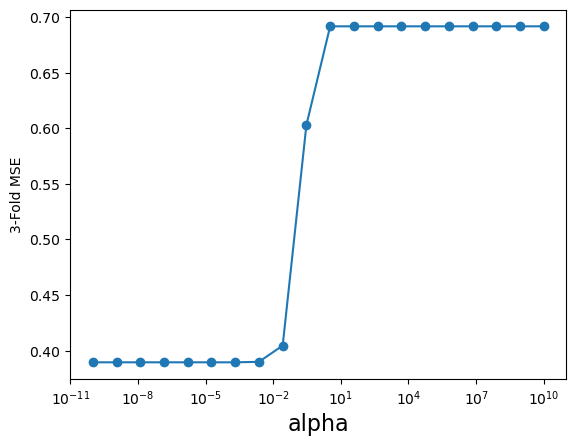

In [8]:
#Vamos a realizar cross validation para buscar el mejor valor para Lasso
alpha_vector = np.logspace(-10,10,20)
param_grid = {'alpha': alpha_vector }
grid = GridSearchCV(Lasso(), scoring='neg_root_mean_squared_error', param_grid=param_grid, cv = 5, n_jobs=2)
grid.fit(XtrainScaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = -1*np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(alpha_vector,scores,'-o')
plt.xlabel('alpha',fontsize=16)
plt.ylabel('3-Fold MSE')
plt.show()

Despues visto el error decidimos probar con un modelo un poco mas complejo como RandomForest usando cross validation para elegir el hiperparámetro maxDepth

best mean cross-validation score: -0.316
best parameters: {'max_depth': 23}


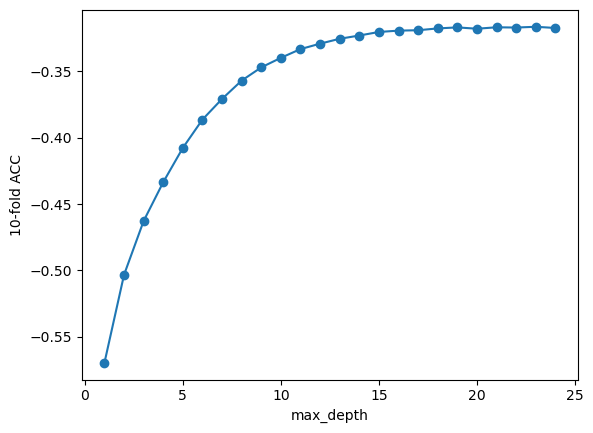

In [ ]:
#RandomForest 
maxDepth = range(1,25)
tuned_parameters = {'max_depth': maxDepth}

grid = GridSearchCV(RandomForestRegressor(random_state=0, n_estimators=200, max_features='sqrt'), param_grid=tuned_parameters,cv=5,scoring='neg_root_mean_squared_error', n_jobs=2) 
grid.fit(XtrainScaled, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth')
plt.ylabel('10-fold ACC')

plt.show()

Imprimimos la importancia de las variables para RandomForest y observamos que hay algunas variables poco importantes podriamos procesarlas y quitarlas de nuestro modelo sin perder valor predictivo apenas para simplificarlo

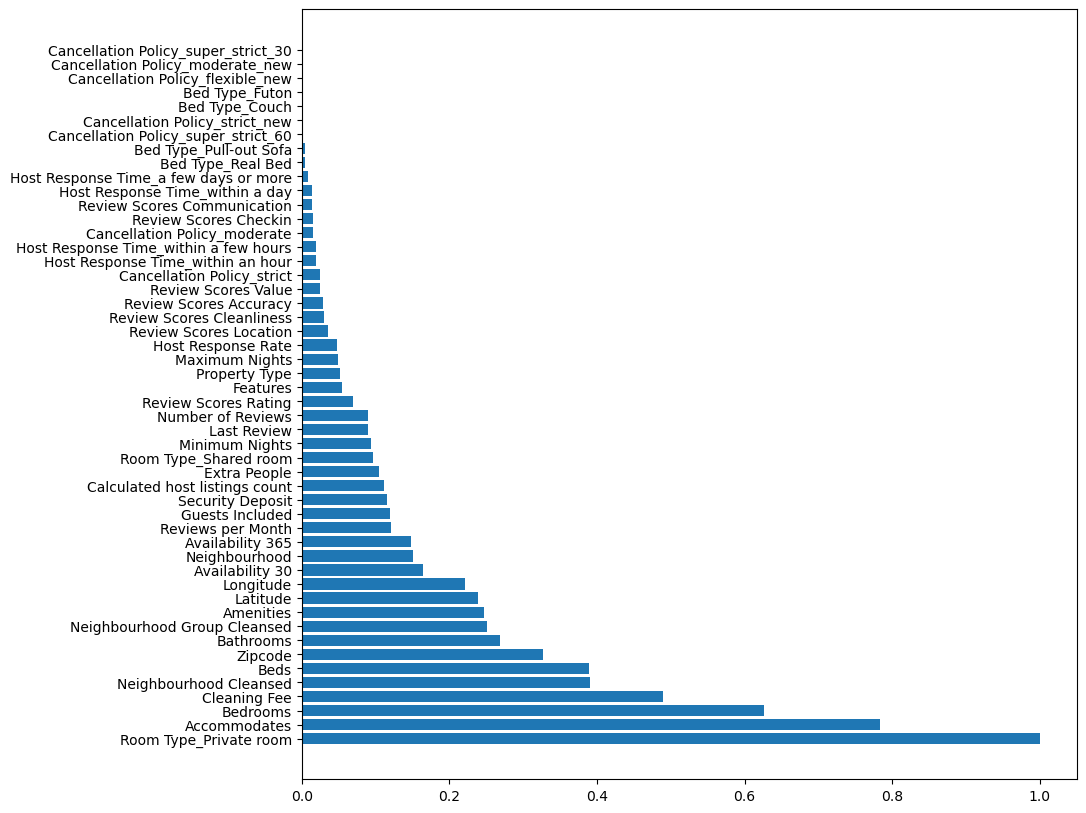

In [ ]:
#Importancia de cada una de las variables
feature_names = X_train_encoded.columns
maxDepthOptimo = grid.best_params_['max_depth']
randomForest = RandomForestRegressor(max_depth=maxDepthOptimo,n_estimators=200,max_features='sqrt').fit(XtrainScaled,y_train)

importances = randomForest.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(XtrainScaled.shape[1]),importances[indices])
plt.yticks(range(XtrainScaled.shape[1]),feature_names[indices])
plt.show()

Decidimos probar con un modelo mas complejo como es XGBoost el cual ya nos da un mucho mejor resultado, el mejor que hemos obtenido hasta ahora. Utilizamos Cross Validation para los hiperparámetros de maxDepth y learning rate


=== MÉTRICAS EN VALIDACIÓN CRUZADA ===
Mejor score (RMSE): 0.2966
Mejor MAE:          0.2128
Mejor R2:           0.8160
best params: {'learning_rate': 0.05, 'max_depth': 4}


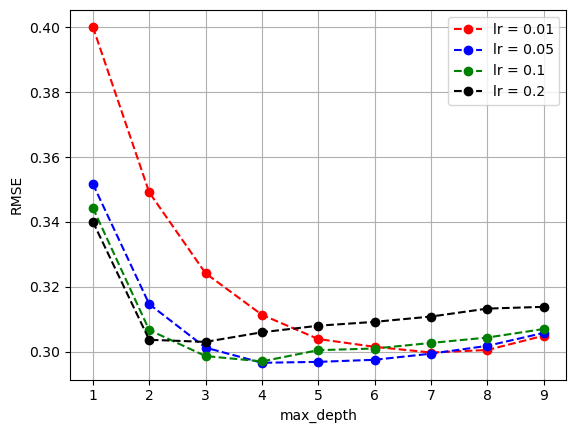

In [ ]:
#con XGBoost
maxDepth = range(1, 10)
learning_rate = [0.01, 0.05, 0.1, 0.2]

gridXGBM = GridSearchCV(
    XGBRegressor(
        random_state=0,
        n_estimators=1000
    ),
    param_grid={
        'max_depth': maxDepth,
        'learning_rate': learning_rate
    },
    cv=5,
    scoring={
        'RMSE': 'neg_root_mean_squared_error', 
        'MAE': 'neg_mean_absolute_error',
        'R2': 'r2'
    },
    refit='RMSE',
    n_jobs=2
)

gridXGBM.fit(XtrainScaled, y_train)


best_rmse_cv = -gridXGBM.cv_results_['mean_test_RMSE'][gridXGBM.best_index_]
best_mae_cv = -gridXGBM.cv_results_['mean_test_MAE'][gridXGBM.best_index_]
best_r2_cv = gridXGBM.cv_results_['mean_test_R2'][gridXGBM.best_index_]

print("\n=== MÉTRICAS EN VALIDACIÓN CRUZADA ===")
print(f"Mejor score (RMSE): {best_rmse_cv:.4f}")
print(f"Mejor MAE:          {best_mae_cv:.4f}")  
print(f"Mejor R2:           {best_r2_cv:.4f}")
print("best params:", gridXGBM.best_params_)

results = gridXGBM.cv_results_
error = -np.array(results['mean_test_RMSE'])
error = error.reshape(len(learning_rate), len(maxDepth))

colors = ['r','b','g','k','m']
for i, lr in enumerate(learning_rate):
    plt.plot(maxDepth, error[i, :], colors[i] + '--o', label=f'lr = {lr}')

plt.legend()
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.grid()
plt.show()

Dado que tenemos muchos datos decidimos Probar con LightGBM que es mas eficiente y rapido nos da casi las mismas metricas que XGBoost pero es mucho mas rápido por lo que es el modelo escogido, usamos cross validation para calcular los mismos hiperparametros que en XGBoost

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003667 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2770
[LightGBM] [Info] Number of data points in the train set: 11729, number of used features: 46
[LightGBM] [Info] Start training from score 4.039088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

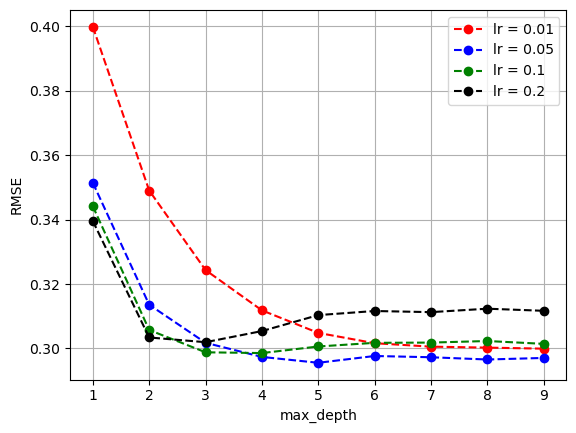

In [ ]:
#vamos a realizar con LightGBM
maxDepth = range(1, 10)
learning_rate = [0.01, 0.05, 0.1, 0.2]

gridLGBM = GridSearchCV(
    LGBMRegressor(
        random_state=0,
        n_estimators=1000
    ),
    param_grid={
        'max_depth': maxDepth,
        'learning_rate': learning_rate
    },
    cv=5,
    scoring={
        'RMSE': 'neg_root_mean_squared_error', 
        'MAE': 'neg_mean_absolute_error',
        'R2': 'r2'
    },
    refit='RMSE',
    n_jobs=2
)

gridLGBM.fit(XtrainScaled, y_train)

best_rmse_cv = -gridLGBM.cv_results_['mean_test_RMSE'][gridLGBM.best_index_]
best_mae_cv = -gridLGBM.cv_results_['mean_test_MAE'][gridLGBM.best_index_]
best_r2_cv = gridLGBM.cv_results_['mean_test_R2'][gridLGBM.best_index_]

print("\n=== MÉTRICAS EN VALIDACIÓN CRUZADA ===")
print(f"Mejor score (RMSE): {best_rmse_cv:.4f}")
print(f"Mejor MAE:          {best_mae_cv:.4f}")  
print(f"Mejor R2:           {best_r2_cv:.4f}")
print("best params:", gridLGBM.best_params_)

results = gridLGBM.cv_results_
error = -np.array(results['mean_test_RMSE'])
error = error.reshape(len(learning_rate), len(maxDepth))

colors = ['r','b','g','k','m']
for i, lr in enumerate(learning_rate):
    plt.plot(maxDepth, error[i, :], colors[i] + '--o', label=f'lr = {lr}')

plt.legend()
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.grid()
plt.show()

Revisamos la importancia de sus caracteristicas para LGBM al igual que en RandomForest hay varias caracteristicas que no aportan casi valor predictivo podriamos eliminarlas para hacer el modelo mas eficiente y sencillo


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2770
[LightGBM] [Info] Number of data points in the train set: 11729, number of used features: 46
[LightGBM] [Info] Start training from score 4.039088
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

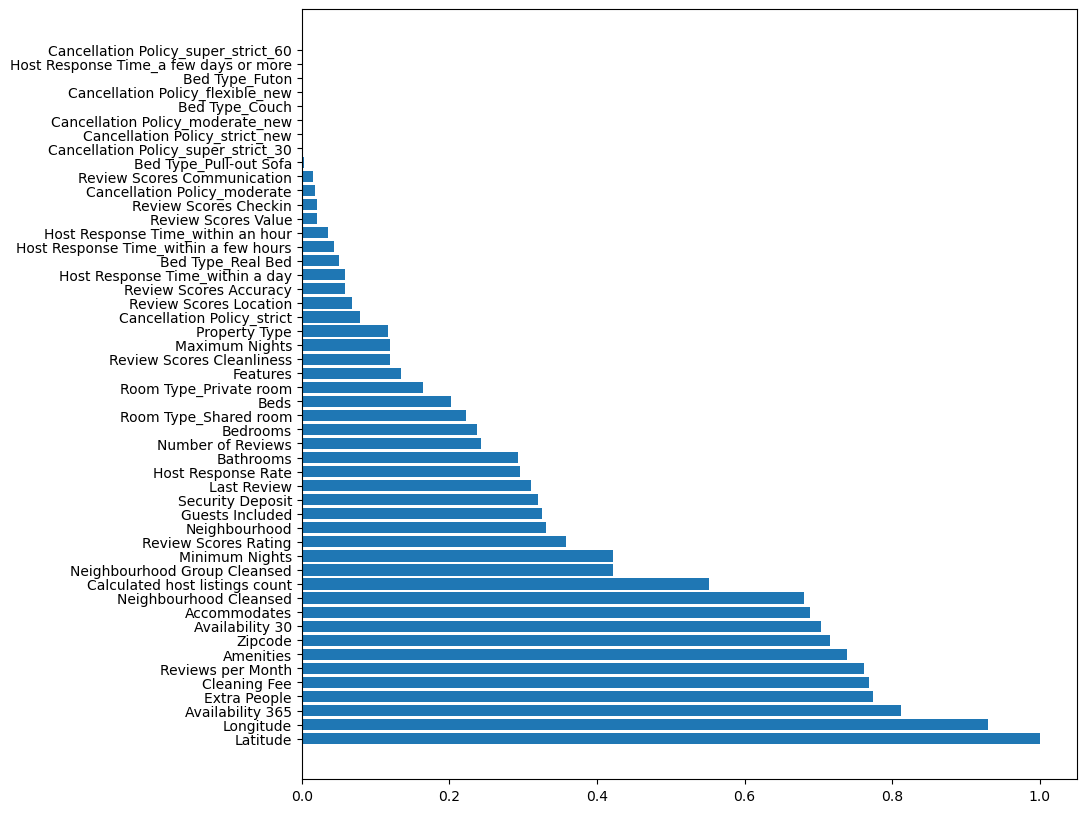

In [ ]:
# Importancia de caracteristicas
feature_names = X_train_encoded.columns
maxDepthOptimo = gridLGBM.best_params_['max_depth']
learningRateOptimo = gridLGBM.best_params_['learning_rate']
lgbm = LGBMRegressor(max_depth=maxDepthOptimo,learning_rate=learningRateOptimo,n_estimators=200).fit(XtrainScaled,y_train)

importances = lgbm.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(XtrainScaled.shape[1]),importances[indices])
plt.yticks(range(XtrainScaled.shape[1]),feature_names[indices])
plt.show()

Por último decidimos probar con una Support Vectorial Machine con kernel rbf, el cual es mucho mas lento e ineficiente y ademas funciona mejor con pocos datos por lo que no nos va a aportar muy buen valor predictivo. Ademas usamos Cross Validation para el vector C y el vector G

best mean cross-validation score: -0.330
best parameters: {'C': np.float64(35.93813663804626), 'gamma': np.float64(0.003727593720314938)}
Gamma en la gráfica:  -2.428571428571429
C en la gráfica:  1.5555555555555554


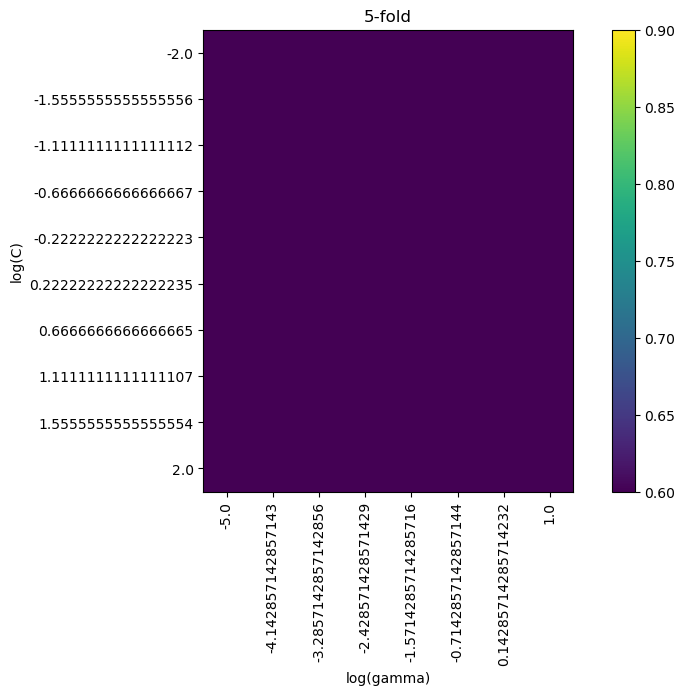

In [ ]:

# con SVM
vectorC = np.logspace(-2, 2, 10)
vectorG = np.logspace(-5, 1, 8)

param_grid = {'C': vectorC, 'gamma':vectorG}

with parallel_backend('threading', n_jobs=4):
    grid = GridSearchCV(SVR(kernel='rbf'), param_grid=param_grid, cv = 5, scoring='neg_root_mean_squared_error',)
    grid.fit(XtrainScaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

print("Gamma en la gráfica: ", np.log10(grid.best_params_['gamma']))
print("C en la gráfica: ", np.log10(grid.best_params_['C']))

# Mostramos prestaciones en CV
scores = grid.cv_results_['mean_test_score'].reshape(len(vectorC),len(vectorG))

plt.figure(figsize=(10,6))
plt.imshow(scores, interpolation='nearest', vmin= 0.6, vmax=0.9)
plt.xlabel('log(gamma)')
plt.ylabel('log(C)')
plt.colorbar()
plt.xticks(np.arange(len(vectorG)), np.log10(vectorG), rotation=90)
plt.yticks(np.arange(len(vectorC)), np.log10(vectorC))
plt.title('5-fold')
plt.show()

Realizamos las predicciones sobre el conjunto de test con el modelo LGBM (el mejor modelo seleccionado). A continuación, revertimos la transformación logarítmica de las predicciones y de nuestra variable objetivo para devolver los valores a su escala original. Finalmente, calculamos las métricas de evaluación (R², RMSE y MAE) para comprobar el rendimiento final del modelo.

--- Resultados en Test ---
RMSE: 37.1508
MAE:  18.0774
R2:   0.6469


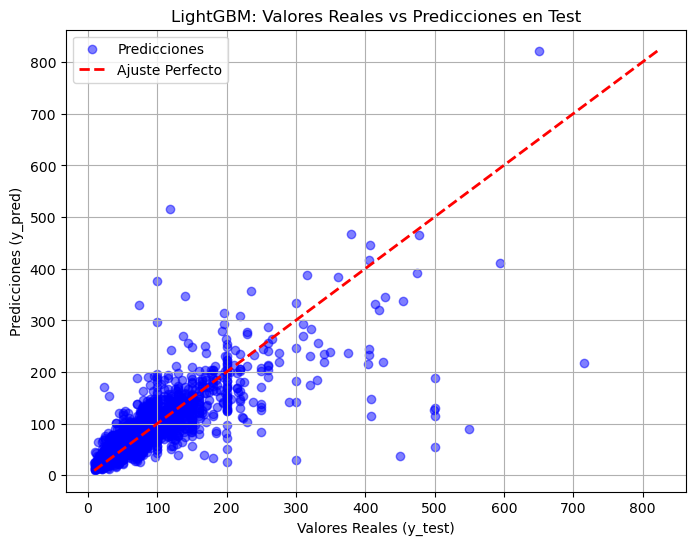

In [ ]:
#Usamos lightgbm para realizar la prediccion ya que aunque XGBM nos dió un poco de mejor resultado lightGBM es mucho mas rapido
y_pred_log = gridLGBM.predict(XtestScaled)

# Volver a escala original
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# 2. Métricas en escala real
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_test = mean_absolute_error(y_test_original, y_pred)
r2_test = r2_score(y_test_original, y_pred)

print("--- Resultados en Test ---")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R2:   {r2_test:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5, color='b', label='Predicciones')

min_val = min(np.min(y_test_original), np.min(y_pred))
max_val = max(np.max(y_test_original), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_pred)')
plt.title('LightGBM: Valores Reales vs Predicciones en Test')
plt.legend()
plt.grid(True)
plt.show()